In [ ]:
import pandas as pd


In [ ]:
file_path="/content/drive/MyDrive/Colab Notebooks/Consumer-Complaint-Intelligence/data/raw/complaints.csv"

sample=pd.read_csv(file_path,nrows=10000)

print("Sample shape:", sample.shape)
print("\nColumns:")
print(sample.columns.tolist())

Sample shape: (10000, 15)

Columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID']


In [ ]:
sample.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,10/2/2023,Mortgage,Conventional home mortgage,Trouble during payment process,Trying to communicate with the company to fix ...,NaN,"CARRINGTON MORTGAGE SERVICES, LLC",GA,30125,NaN,Web,10/2/2023,Closed with explanation,Yes,7622067
1,10/9/2023,Mortgage,Conventional home mortgage,Incorrect information on your report,Account status incorrect,Company believes complaint represents an oppor...,HOMESTAR FINANCIAL CORPORATION,GA,30125,NaN,Web,10/9/2023,Closed with explanation,Yes,7668706
2,12/9/2023,Mortgage,Conventional home mortgage,Applying for a mortgage or refinancing an exis...,Trying to communicate with the company to fix ...,NaN,"CARRINGTON MORTGAGE SERVICES, LLC",GA,30125,NaN,Web,12/9/2023,Closed with explanation,Yes,7975149
3,5/6/2024,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,"EQUIFAX, INC.",GA,30214,NaN,Web,5/6/2024,Closed with non-monetary relief,Yes,8939864
4,6/17/2024,Checking or savings account,Checking account,Managing an account,Problem accessing account,Company has responded to the consumer and the ...,M&T BANK CORPORATION,NY,14541,NaN,Phone,6/17/2024,Closed with explanation,Yes,9277756


In [ ]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 10000 non-null  object
 1   Product                       10000 non-null  object
 2   Sub-product                   10000 non-null  object
 3   Issue                         10000 non-null  object
 4   Sub-issue                     9861 non-null   object
 5   Company public response       8562 non-null   object
 6   Company                       10000 non-null  object
 7   State                         9986 non-null   object
 8   ZIP code                      9985 non-null   object
 9   Tags                          266 non-null    object
 10  Submitted via                 10000 non-null  object
 11  Date sent to company          10000 non-null  object
 12  Company response to consumer  10000 non-null  object
 13  Timely response? 

In [ ]:
sample.isnull().sum().sort_values(ascending=False)

,0
Tags,9734
Company public response,1438
Sub-issue,139
ZIP code,15
State,14
Sub-product,0
Date received,0
Company,0
Issue,0
Product,0


In [ ]:
sample.nunique().sort_values(ascending=False)

,0
Complaint ID,10000
ZIP code,4563
Company,264
Sub-issue,141
Date sent to company,125
Date received,119
Issue,65
State,55
Sub-product,41
Product,11


In [ ]:
import csv

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    row_count = sum(1 for _ in f) - 1

print("Total rows:", row_count)

Total rows: 1048488


In [ ]:
import os
import pandas as pd

print("File exists:", os.path.exists(file_path))
print("File size (GB):", round(os.path.getsize(file_path) / (1024**3), 2))

# Check first 10,000 rows
sample = pd.read_csv(file_path, nrows=10000)

print("Sample shape:", sample.shape)
print("Columns:", sample.columns.tolist())

File exists: True
File size (GB): 0.28
Sample shape: (10000, 15)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID']


In [ ]:
with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    total_rows = sum(1 for _ in f) - 1

print("Total rows:", total_rows)

Total rows: 1048488


In [ ]:
# Load the complete project dataset
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nDate range:")
print(df["Date received"].min(), "to", df["Date received"].max())

print("\nDuplicate Complaint IDs:")
print(df["Complaint ID"].duplicated().sum())

print("\nUnique Complaint IDs:")
print(df["Complaint ID"].nunique())

Shape: (1048488, 15)

Date range:
1/1/2023 to 9/9/2026

Duplicate Complaint IDs:
0

Unique Complaint IDs:
1048488


In [ ]:
df["Date received"] = pd.to_datetime(
    df["Date received"],
    errors="coerce"
)

print(df["Date received"].describe())

count                          1048488
mean     2025-09-11 20:05:48.076086528
min                2021-09-29 00:00:00
25%                2023-05-26 00:00:00
50%                2026-08-26 00:00:00
75%                2026-09-11 00:00:00
max                2026-09-26 00:00:00
Name: Date received, dtype: object


In [ ]:
print(df["Date received"].isnull().sum())

0


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace("?", "", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df.columns.tolist()

['date_received',
 'product',
 'sub_product',
 'issue',
 'sub_issue',
 'company_public_response',
 'company',
 'state',
 'zip_code',
 'tags',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'complaint_id']

In [ ]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})

missing.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
tags,1010591,96.39
company_public_response,661059,63.05
sub_issue,18162,1.73
state,1031,0.10
zip_code,659,0.06
sub_product,0,0.00
date_received,0,0.00
company,0,0.00
issue,0,0.00
product,0,0.00


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Complaint IDs:", df["complaint_id"].duplicated().sum())

Duplicate rows: 0
Duplicate Complaint IDs: 0


In [ ]:
# Clean whitespace in categorical/text columns
text_columns = [
    "product",
    "sub_product",
    "issue",
    "sub_issue",
    "company_public_response",
    "company",
    "state",
    "zip_code",
    "tags",
    "submitted_via",
    "company_response_to_consumer",
    "timely_response"
]

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()


In [ ]:
# Meaningful missing-value labels
df["tags"] = df["tags"].fillna("Not provided")
df["company_public_response"] = df["company_public_response"].fillna(
    "No public response"
)
df["sub_issue"] = df["sub_issue"].fillna("Unknown")
df["state"] = df["state"].fillna("Unknown")
df["zip_code"] = df["zip_code"].fillna("Unknown")
df["company_response_to_consumer"] = df["company_response_to_consumer"].fillna(
    "Unknown"
)


In [ ]:
print("Missing values after handling:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Missing values after handling:
date_received              0
product                    0
sub_product                0
issue                      0
sub_issue                  0
company_public_response    0
company                    0
state                      0
zip_code                   0
tags                       0
dtype: int64


In [ ]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Complaint IDs:", df["complaint_id"].duplicated().sum())

Rows: 1048488
Columns: 15
Duplicate rows: 0
Duplicate Complaint IDs: 0


In [ ]:
df["date_received"] = pd.to_datetime(
    df["date_received"],
    errors="coerce"
)

df["date_sent_to_company"] = pd.to_datetime(
    df["date_sent_to_company"],
    errors="coerce"
)

print(df[["date_received", "date_sent_to_company"]].dtypes)

date_received           datetime64[ns]
date_sent_to_company    datetime64[ns]
dtype: object


In [ ]:
print("Start:", df["date_received"].min())
print("End:", df["date_received"].max())
print("Invalid dates:", df["date_received"].isna().sum())

Start: 2021-09-29 00:00:00
End: 2026-09-26 00:00:00
Invalid dates: 0


In [ ]:
df["year"] = df["date_received"].dt.year
df["month"] = df["date_received"].dt.month
df["month_name"] = df["date_received"].dt.month_name()
df["quarter"] = df["date_received"].dt.quarter
df["day_of_week"] = df["date_received"].dt.day_name()

In [ ]:
df["response_days"] = (
    df["date_sent_to_company"] - df["date_received"]
).dt.days

df["response_days"].describe()

,response_days
count,1.048488e+06
mean,3.438523e-01
std,3.944698e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,5.440000e+02


In [ ]:
print("Negative response days:", (df["response_days"] < 0).sum())
print("Missing response days:", df["response_days"].isna().sum())

Negative response days: 0
Missing response days: 0


In [ ]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Unique companies:", df["company"].nunique())
print("Products:", df["product"].nunique())
print("Issues:", df["issue"].nunique())
print("States:", df["state"].nunique())

Rows: 1048488
Columns: 21
Unique companies: 2657
Products: 14
Issues: 92
States: 62


In [ ]:
import os

processed_dir = "/content/drive/MyDrive/Colab Notebooks/Consumer-Complaint-Intelligence/data/processed"

os.makedirs(processed_dir, exist_ok=True)

In [ ]:
processed_path = os.path.join(
    processed_dir,
    "cfpb_complaints_cleaned.csv"
)

df.to_csv(processed_path, index=False)

print("Saved:", processed_path)

Saved: /content/drive/MyDrive/Colab Notebooks/Consumer-Complaint-Intelligence/data/processed/cfpb_complaints_cleaned.csv


In [ ]:
print("Final shape:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Final shape: (1048488, 21)

Data types:
date_received                   datetime64[ns]
product                         string[python]
sub_product                     string[python]
issue                           string[python]
sub_issue                       string[python]
company_public_response         string[python]
company                         string[python]
state                           string[python]
zip_code                        string[python]
tags                            string[python]
submitted_via                   string[python]
date_sent_to_company            datetime64[ns]
company_response_to_consumer    string[python]
timely_response                 string[python]
complaint_id                             int64
year                                     int32
month                                    int32
month_name                              object
quarter                                  int32
day_of_week                             object
response_days       

#**EDA**

In [76]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Date range:", df["date_received"].min().date(),
      "to", df["date_received"].max().date())
print("Unique companies:", df["company"].nunique())
print("Unique products:", df["product"].nunique())
print("Unique issues:", df["issue"].nunique())
print("States:", df["state"].nunique())

Rows: 1048488
Columns: 21
Date range: 2021-09-29 to 2026-09-26
Unique companies: 2657
Unique products: 14
Unique issues: 92
States: 62


Complaint trends over time

In [77]:
yearly_complaints = (
    df.groupby("year")
      .size()
      .reset_index(name="complaint_count")
)

yearly_complaints

,year,complaint_count
0,2021,9
1,2022,54
2,2023,302107
3,2024,245
4,2025,389
5,2026,745684


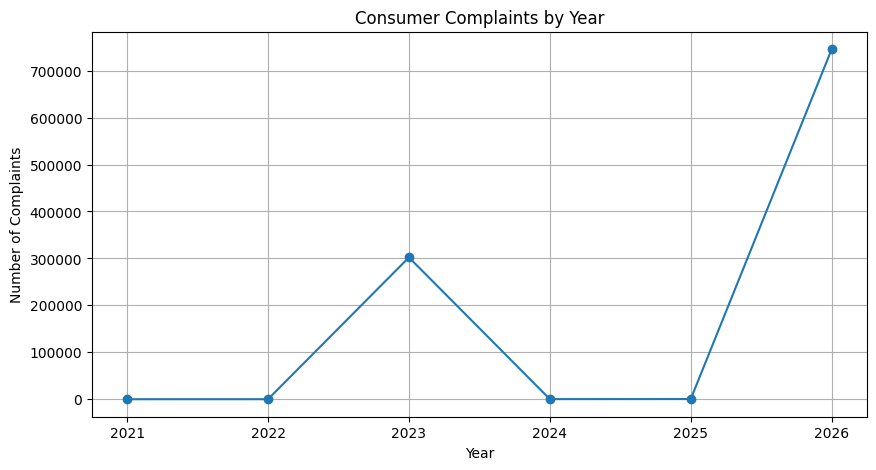

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(
    yearly_complaints["year"],
    yearly_complaints["complaint_count"],
    marker="o"
)

plt.title("Consumer Complaints by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.grid(True)
plt.show()

Monthly trend

In [79]:
monthly_complaints = (
    df.groupby(df["date_received"].dt.to_period("M"))
      .size()
      .reset_index(name="complaint_count")
)

monthly_complaints["date"] = monthly_complaints["date_received"].dt.to_timestamp()

monthly_complaints.head()

,date_received,complaint_count,date
0,2021-09,1,2021-09-01
1,2021-10,4,2021-10-01
2,2021-11,3,2021-11-01
3,2021-12,1,2021-12-01
4,2022-01,4,2022-01-01


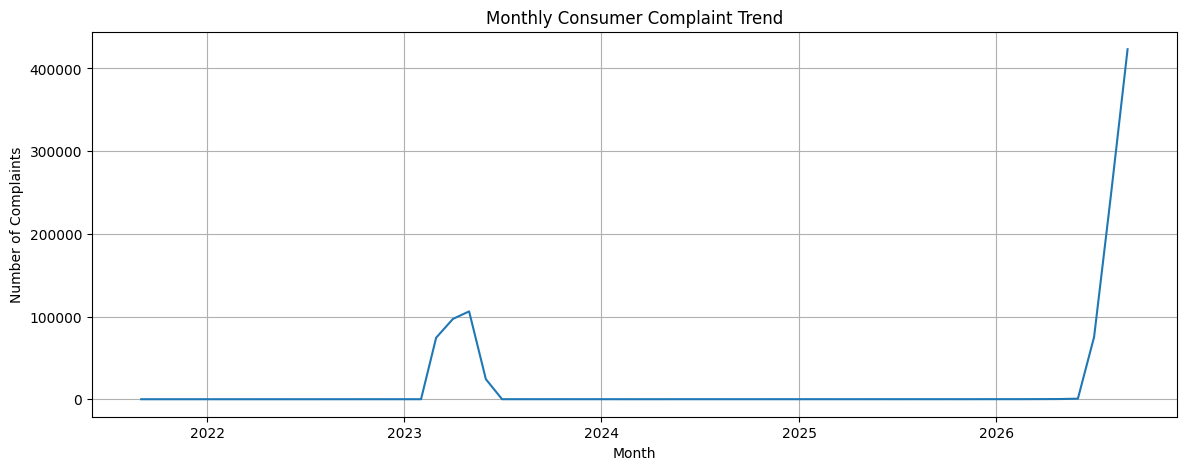

In [80]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_complaints["date"],
    monthly_complaints["complaint_count"]
)

plt.title("Monthly Consumer Complaint Trend")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.grid(True)
plt.show()

Product analysis

In [82]:
product_counts = (
    df["product"]
    .value_counts()
    .reset_index()
)
product_counts.columns = ["product", "complaint_count"]

product_counts.head(15)

,product,complaint_count
0,Credit reporting or other personal consumer re...,696997
1,"Credit reporting, credit repair services, or o...",246997
2,Debt collection,37268
3,Checking or savings account,19458
4,Credit card or prepaid card,12132
5,Mortgage,8474
6,Credit card,8304
7,"Money transfer, virtual currency, or money ser...",6423
8,Vehicle loan or lease,5182
9,Student loan,2859


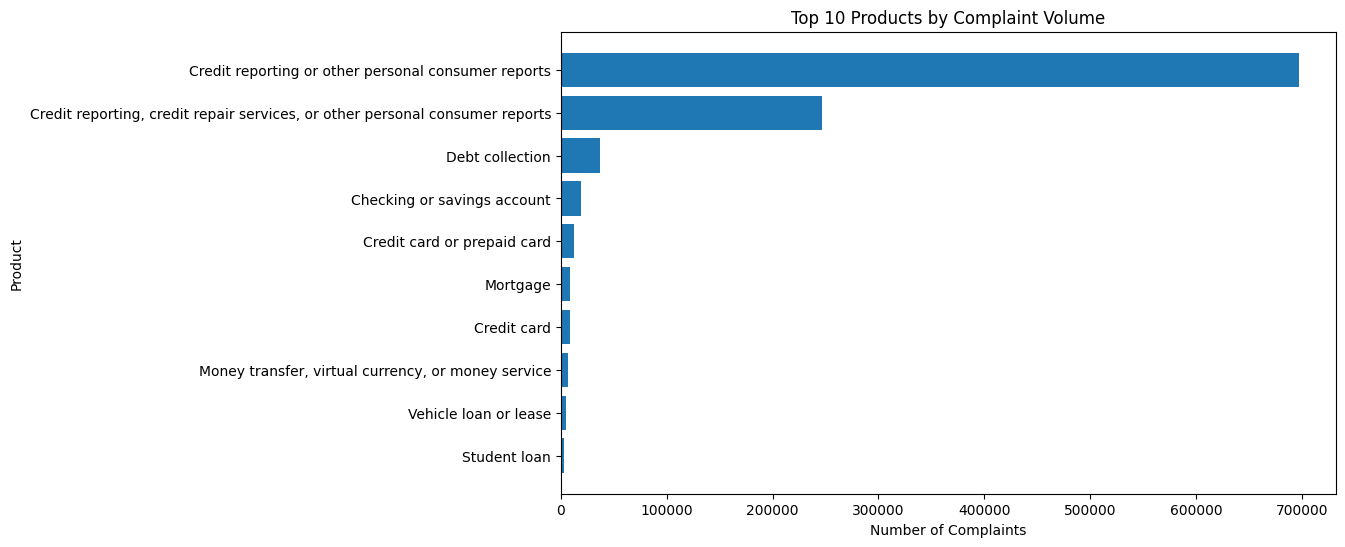

In [83]:
top_products = product_counts.head(10).sort_values("complaint_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top_products["product"],
    top_products["complaint_count"]
)

plt.title("Top 10 Products by Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Product")
plt.show()

Issue analysis

In [85]:
issue_counts = (
    df["issue"]
    .value_counts()
    .reset_index()
)
issue_counts.columns = ["issue", "complaint_count"]

issue_counts.head(15)

,issue,complaint_count
0,Incorrect information on your report,513598
1,Improper use of your report,218286
2,Problem with a company's investigation into an...,139250
3,Problem with a credit reporting company's inve...,69142
4,Attempts to collect debt not owed,19321
5,Managing an account,11440
6,Written notification about debt,6616
7,Problem with a purchase shown on your statement,5747
8,False statements or representation,4338
9,Trouble during payment process,4158


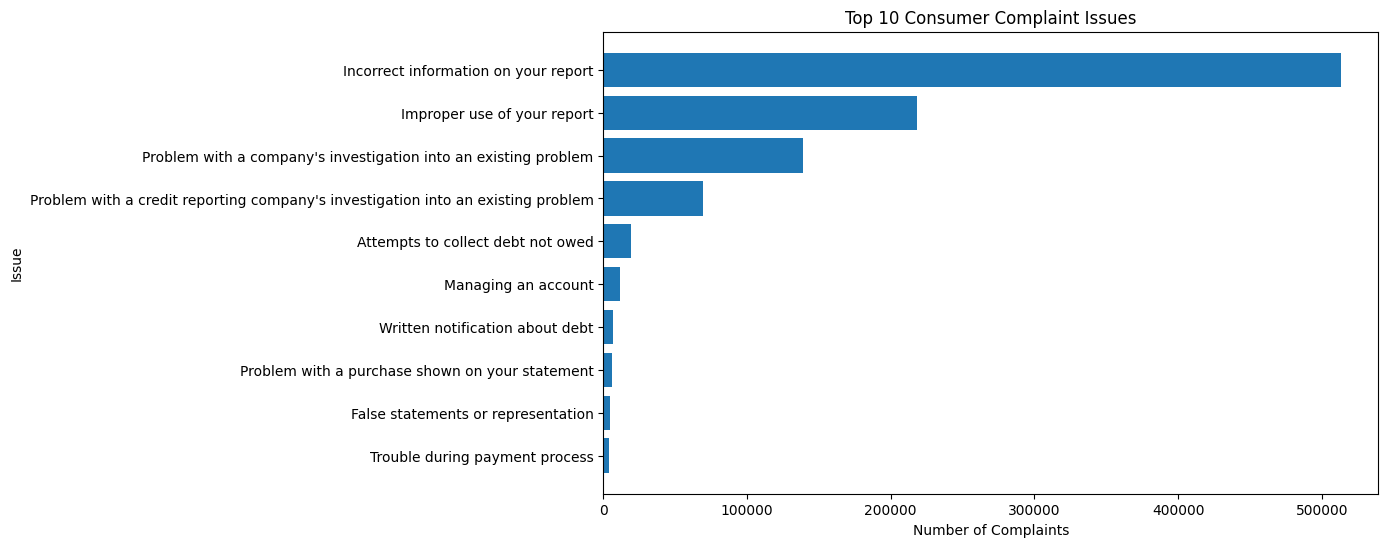

In [86]:
top_issues = issue_counts.head(10).sort_values("complaint_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top_issues["issue"],
    top_issues["complaint_count"]
)

plt.title("Top 10 Consumer Complaint Issues")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")
plt.show()

Product × Issue analysis

In [87]:
product_issue = pd.crosstab(
    df["product"],
    df["issue"]
)

product_issue.shape

(14, 92)

In [88]:
product_issue_top = (
    df.groupby(["product", "issue"])
      .size()
      .reset_index(name="complaint_count")
      .sort_values(
          ["product", "complaint_count"],
          ascending=[True, False]
      )
)

product_issue_top.head(20)

,product,issue,complaint_count
4,Checking or savings account,Managing an account,11440
0,Checking or savings account,Closing an account,2580
9,Checking or savings account,Problem with a lender or other company chargin...,2472
5,Checking or savings account,Opening an account,1825
6,Checking or savings account,Problem caused by your funds being low,1027
3,Checking or savings account,Incorrect information on your report,49
7,Checking or savings account,Problem with a company's investigation into an...,22
2,Checking or savings account,Improper use of your report,15
1,Checking or savings account,Credit monitoring or identity theft protection...,10
10,Checking or savings account,Problem with fraud alerts or security freezes,10


Company analysis

In [90]:
company_counts = (
    df["company"]
    .value_counts()
    .reset_index()
)
company_counts.columns = ["company", "complaint_count"]

company_counts.head(20)

,company,complaint_count
0,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",364931
1,Experian Information Solutions Inc.,307781
2,"EQUIFAX, INC.",241674
3,CAPITAL ONE FINANCIAL CORPORATION,6686
4,WELLS FARGO & COMPANY,6319
5,"BANK OF AMERICA, NATIONAL ASSOCIATION",5586
6,JPMORGAN CHASE & CO.,5299
7,"CITIBANK, N.A.",3991
8,LEXISNEXIS,3618
9,SYNCHRONY FINANCIAL,3174


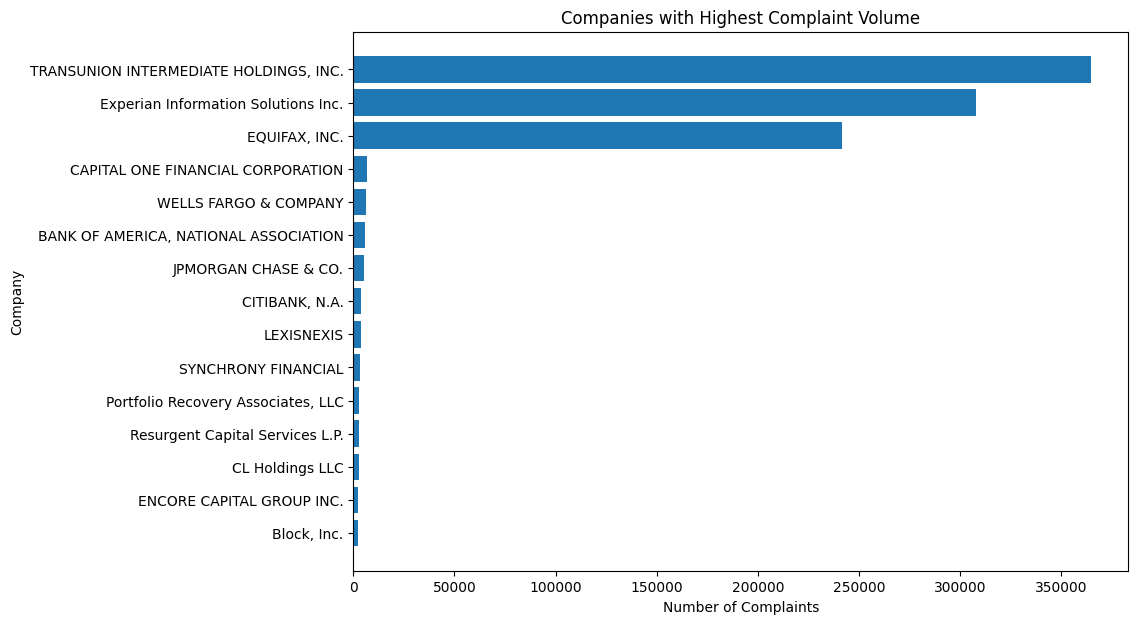

In [91]:
top_companies = company_counts.head(15).sort_values("complaint_count")

plt.figure(figsize=(10, 7))

plt.barh(
    top_companies["company"],
    top_companies["complaint_count"]
)

plt.title("Companies with Highest Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("Company")
plt.show()

State analysis

In [93]:
state_counts = (
    df["state"]
    .value_counts()
    .reset_index()
)
state_counts.columns = ["state", "complaint_count"]

state_counts.head(20)

,state,complaint_count
0,TX,158691
1,FL,145590
2,CA,97045
3,GA,77429
4,NY,54231
5,IL,44162
6,PA,39622
7,NC,39309
8,NJ,31132
9,AL,30494


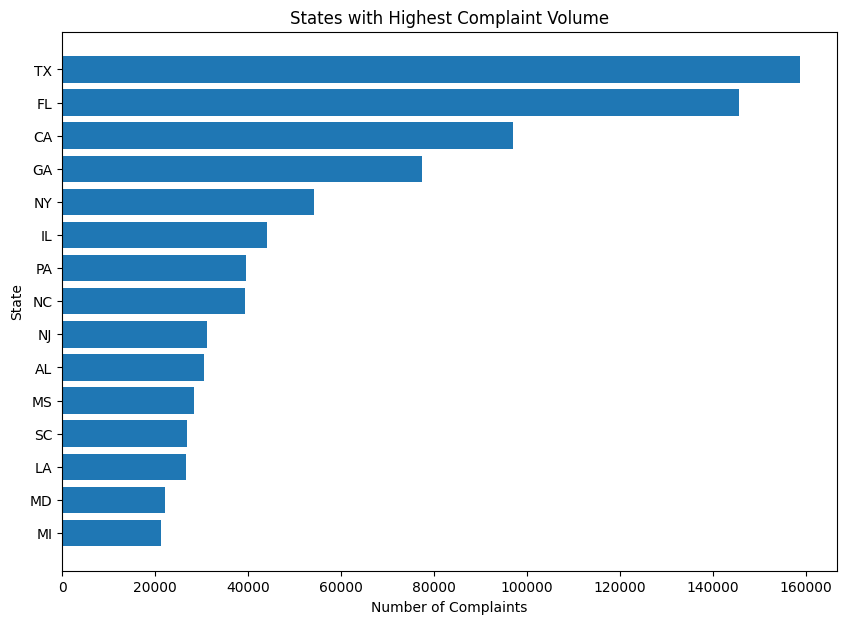

In [94]:
top_states = state_counts.head(15).sort_values("complaint_count")

plt.figure(figsize=(10, 7))

plt.barh(
    top_states["state"],
    top_states["complaint_count"]
)

plt.title("States with Highest Complaint Volume")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.show()

Submission channel

In [96]:
submission_counts = (
    df["submitted_via"]
    .value_counts()
    .reset_index()
)
submission_counts.columns = ["submitted_via", "complaint_count"]

submission_counts

,submitted_via,complaint_count
0,Web,1036871
1,Phone,7206
2,Referral,2695
3,Postal mail,1716


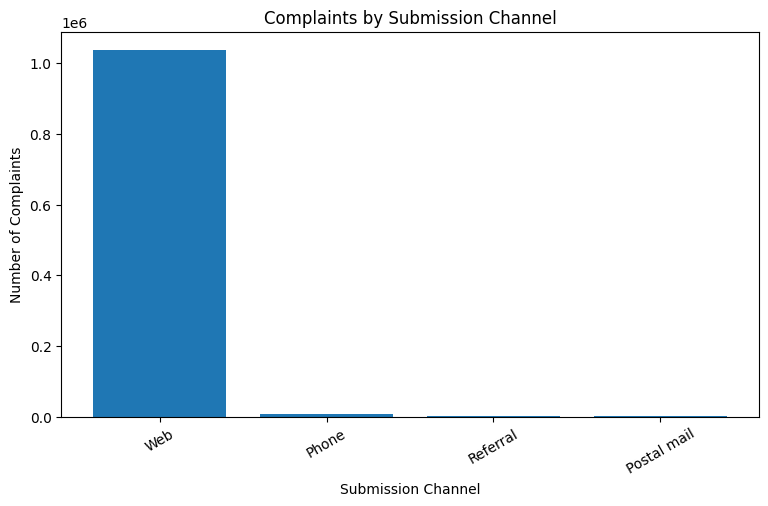

In [97]:
plt.figure(figsize=(9, 5))

plt.bar(
    submission_counts["submitted_via"],
    submission_counts["complaint_count"]
)

plt.title("Complaints by Submission Channel")
plt.xlabel("Submission Channel")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30)
plt.show()

Timely response analysis

In [100]:
timely_counts = (
    df["timely_response"]
    .value_counts()
    .reset_index()
)
timely_counts.columns = ["timely_response", "complaint_count"]

timely_counts

,timely_response,complaint_count
0,Yes,1045341
1,No,3147


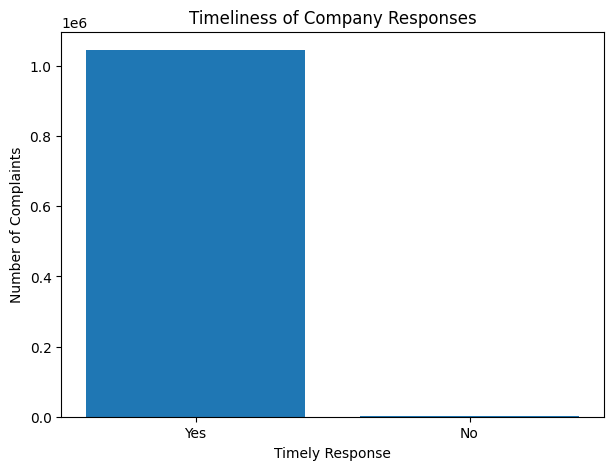

In [101]:
plt.figure(figsize=(7, 5))

plt.bar(
    timely_counts["timely_response"],
    timely_counts["complaint_count"]
)

plt.title("Timeliness of Company Responses")
plt.xlabel("Timely Response")
plt.ylabel("Number of Complaints")
plt.show()

Company response analysis

In [103]:
response_counts = (
    df["company_response_to_consumer"]
    .value_counts()
    .reset_index()
)
response_counts.columns = [
    "company_response_to_consumer",
    "complaint_count"
]

response_counts

,company_response_to_consumer,complaint_count
0,Closed with explanation,445564
1,In progress,382317
2,Closed with non-monetary relief,212200
3,Closed with monetary relief,6713
4,Untimely response,1693
5,Unknown,1


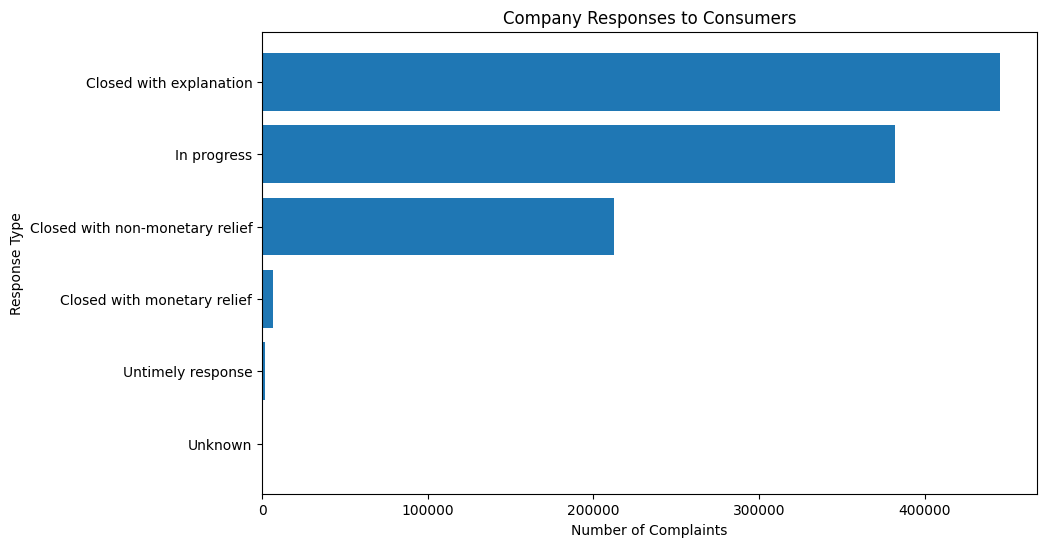

In [104]:
top_responses = response_counts.head(10).sort_values("complaint_count")

plt.figure(figsize=(10, 6))

plt.barh(
    top_responses["company_response_to_consumer"],
    top_responses["complaint_count"]
)

plt.title("Company Responses to Consumers")
plt.xlabel("Number of Complaints")
plt.ylabel("Response Type")
plt.show()

Response time analysis

In [105]:
df["response_days"].describe()

,response_days
count,1.048488e+06
mean,3.438523e-01
std,3.944698e+00
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,5.440000e+02


In [106]:
valid_response = df[
    df["response_days"].between(0, 365)
]

print("Valid records:", len(valid_response))
print("Excluded from response-time analysis:",
      len(df) - len(valid_response))

Valid records: 1048485
Excluded from response-time analysis: 3


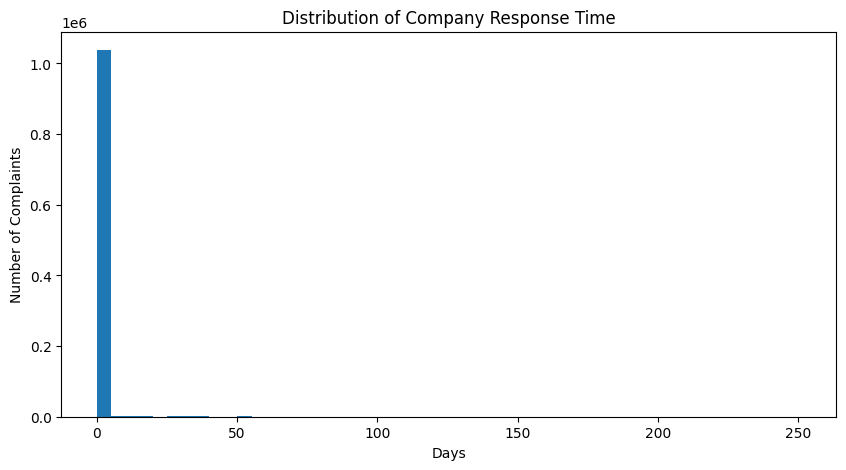

In [107]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_response["response_days"],
    bins=50
)

plt.title("Distribution of Company Response Time")
plt.xlabel("Days")
plt.ylabel("Number of Complaints")
plt.show()

Key cross-analysis

In [109]:
timely_by_product = pd.crosstab(
    df["product"],
    df["timely_response"],
    normalize="index"
) * 100

timely_by_product.round(2)

timely_response,No,Yes
product,,
Checking or savings account,0.86,99.14
Credit card,1.19,98.81
Credit card or prepaid card,0.63,99.37
Credit reporting or other personal consumer reports,0.06,99.94
"Credit reporting, credit repair services, or other personal consumer reports",0.12,99.88
Debt collection,2.75,97.25
Debt or credit management,11.55,88.45
"Money transfer, virtual currency, or money service",1.60,98.40
Mortgage,2.62,97.38


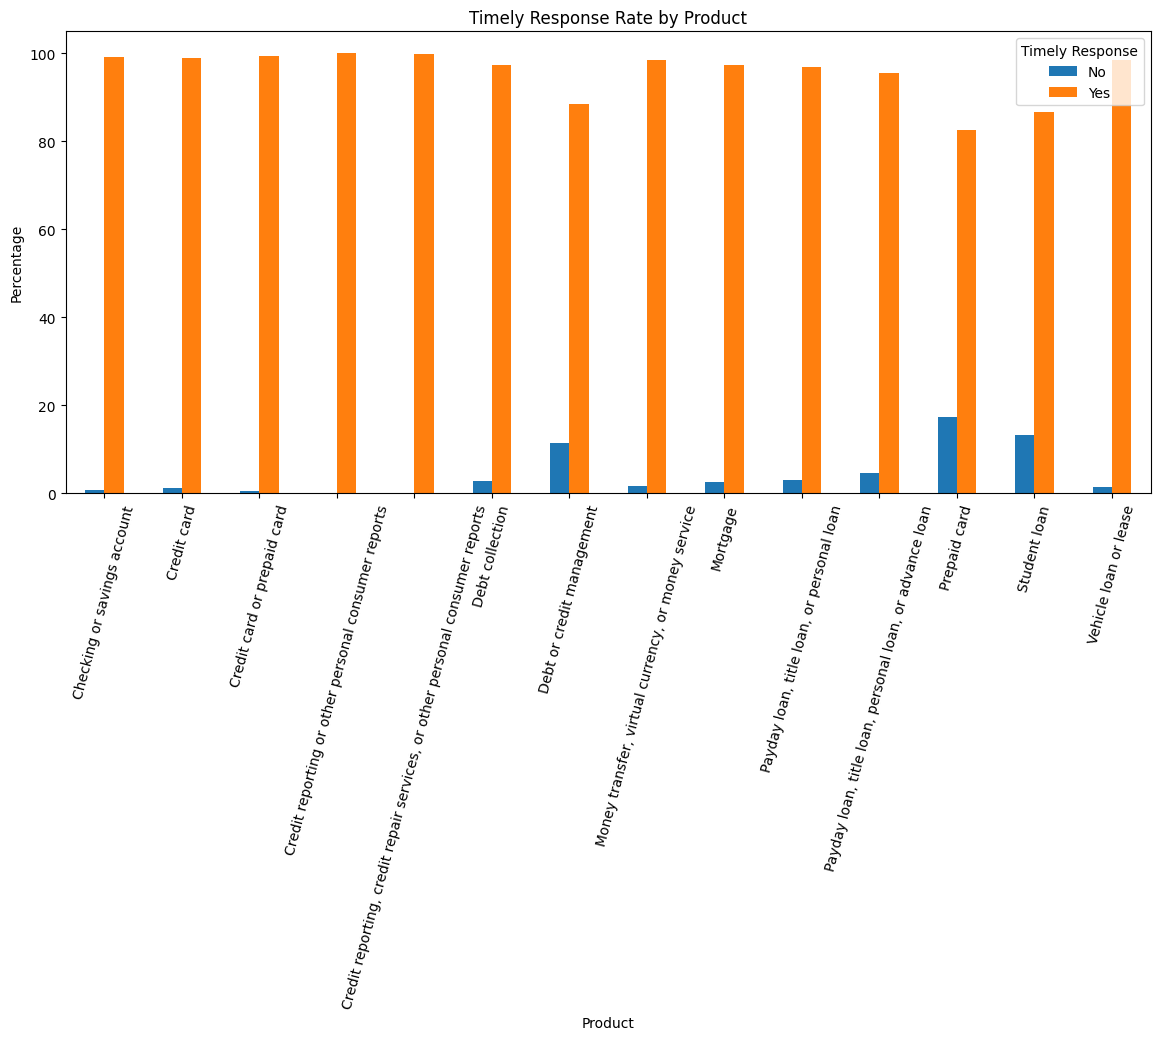

In [110]:
timely_by_product.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Timely Response Rate by Product")
plt.xlabel("Product")
plt.ylabel("Percentage")
plt.xticks(rotation=75)
plt.legend(title="Timely Response")
plt.show()

Save EDA outputs